In [1]:
import scanpy as sc
import os
import numpy as np
import pandas as pd


# 1. Path to your .h5ad file
FILE_PATH = "GSM6061702_GSM6061683.h5ad"  

# --- 1. Load and Light Preprocessing ---
if not os.path.exists(FILE_PATH):
    raise FileNotFoundError(f"Could not find {FILE_PATH}")

adata = sc.read_h5ad(FILE_PATH)

In [2]:
adata.layers["counts"] = adata.X.copy()

# Normalizing to median total counts
sc.pp.normalize_total(adata, target_sum = 1e4)
# Logarithmize the data
sc.pp.log1p(adata)

sc.pp.highly_variable_genes(adata, n_top_genes=2000)
sc.tl.pca(adata)

# --- Custom Parameters ---
ndim = 2           # Number of UMAP dimensions
n_neighbors = 15   # Number of neighbors for the graph
my_res = 1.0       # Clustering resolution (changed from 2.0 to 1.0 as requested)
algo_cluster = "leidenalg"
npca = 50
cluster_key = f'leiden_{my_res}' # Renamed key to reflect global clustering


# 5. Neighbors and UMAP (Step 8)
# This step uses the 50-component PCA result (final_adata.obsm['X_pca'])
print(f"Computing nearest neighbors (k={n_neighbors}) and UMAP (n_dims={ndim})...")
sc.pp.neighbors(adata, n_neighbors=n_neighbors, use_rep = "X_pca", n_pcs=npca) # Stored in neighboars
sc.tl.umap(adata, n_components=ndim, maxiter=500)

sc.tl.leiden(
    adata,
    flavor=algo_cluster,
    n_iterations=2, # Use n_iterations=2 as in the previous code
    resolution=my_res,
    key_added=cluster_key,
)


Computing nearest neighbors (k=15) and UMAP (n_dims=2)...


C:\Users\selim\AppData\Local\Temp\ipykernel_6756\669211214.py:26: FutureWarning: In the future, the default backend for leiden will be igraph instead of leidenalg.

 To achieve the future defaults please pass: flavor="igraph" and n_iterations=2.  directed must also be False to work with igraph's implementation.
  sc.tl.leiden(


In [3]:
adata

AnnData object with n_obs × n_vars = 7489 × 17238
    obs: 'CellID', 'BatchID', 'ClusterID', 'CellType', 'CellCycle', 'leiden_1.0'
    var: 'highly_variable', 'means', 'dispersions', 'dispersions_norm'
    uns: 'log1p', 'hvg', 'pca', 'neighbors', 'umap', 'leiden_1.0'
    obsm: 'X_pca', 'X_umap'
    varm: 'PCs'
    layers: 'counts'
    obsp: 'distances', 'connectivities'

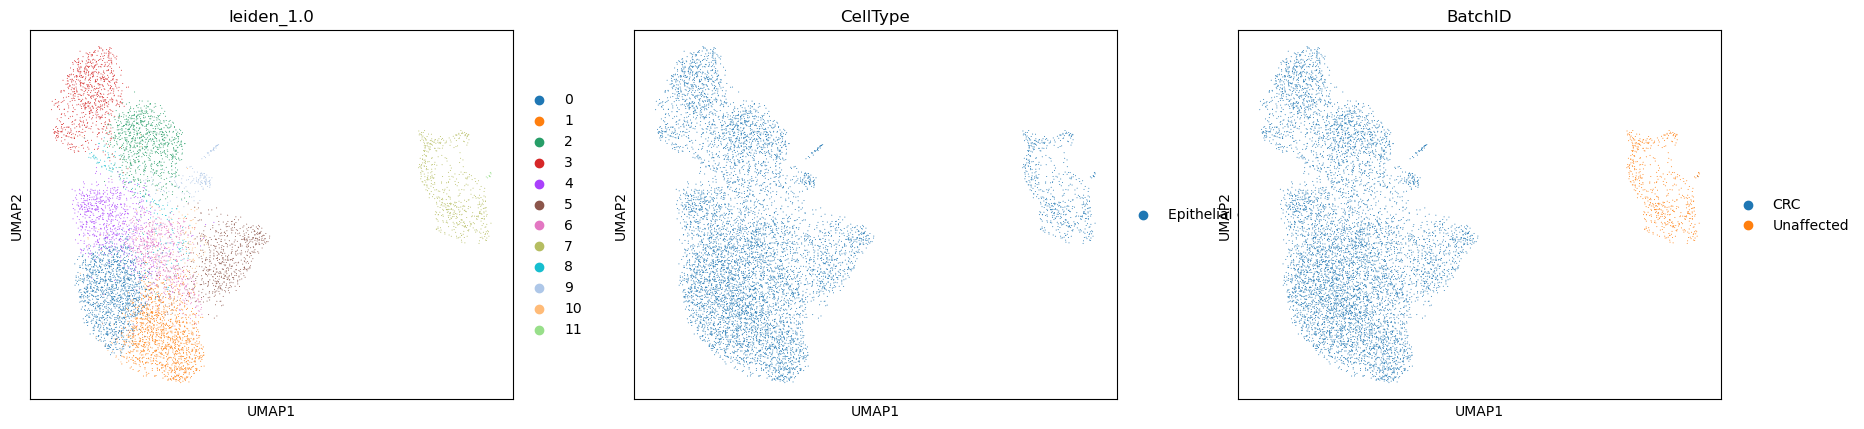

In [4]:
sc.pl.umap(
    adata,
    color=[cluster_key,"CellType", "BatchID"],
    # Setting a smaller point size to get prevent overlap
    size=2
    )

In [ ]:
import numpy as np
import pandas as pd
import scanpy as sc
from scipy.interpolate import BSpline
from scipy.stats import zscore, norm
from sklearn.neighbors import NearestNeighbors
from scipy.sparse import diags
import matplotlib.pyplot as plt

def sc_genestat(adata, obs_label, label):
    """
    Computes gene-level descriptive statistics from normalized single-cell data.
    
    MOTIVATION:
    To identify genes with differential variability, we must first map them into a 
    3D space defined by Mean Expression, Coefficient of Variation (CV), and Dropout Rate.
    This function extracts these metrics from linear space (to maintain statistical 
    integrity) but returns them in a log-transformed space suitable for 3D manifold fitting.

    LOGIC:
    1. Subsetting: Isolates cells belonging to a specific condition/label.
    2. Linear Stats: Computes Mean (u) and Standard Deviation (std) on normalized counts.
    3. CV Calculation: Standardizes dispersion (std/u). Small epsilon (1e-9) prevents 
       division by zero for unexpressed genes.
    4. Dropout Rate: Calculates the fraction of zero-values, a critical metric for 
       identifying technical noise vs. biological signal in scRNA-seq.
    5. Log Transformation: Applies log1p to Mean and CV to compress the dynamic range, 
       ensuring the 3D spline fit isn't skewed by extreme outliers.

    Parameters:
    -----------
    adata : AnnData
        Annotated data object containing the gene expression matrix.
    obs_label : str
        The column in adata.obs used for grouping (e.g., 'BatchID' or 'Condition').
    label : str
        The specific group to analyze (e.g., 'Unaffected' or 'CRC').

    Returns:
    --------
    pd.DataFrame
        A table indexed by gene names containing:
        - 'lgu': Log-transformed mean expression.
        - 'lgcv': Log-transformed Coefficient of Variation.
        - 'dropout': The zero-expression frequency per gene.

    Author: Selim Romero, Texas A&M University
    Date: February 14, 2026
    """
    # 1. Identify and extract cells for the specific condition
    idx = adata.obs[obs_label] == label
    X = adata[idx].X
    
    # Ensure the matrix is in a dense format for calculation if it is stored as sparse
    if hasattr(X, "toarray"): 
        X = X.toarray()
    
    # 2. Calculate statistics in Linear Space
    # We work directly on normalized counts to preserve the relationship between mean and variance
    u = np.mean(X, axis=0)
    std = np.std(X, axis=0)
    
    # 3. Compute Coefficient of Variation (CV)
    # CV = Standard Deviation / Mean. Epsilon (1e-9) handles genes with zero mean.
    cv = np.divide(std, u + 1e-9, out=np.zeros_like(u))
    
    # 4. Compute Dropout Rate
    # The proportion of cells where the gene expression is exactly zero.
    dropr = np.mean(X == 0, axis=0)
    
    # 5. Build the 3D Manifold Coordinate Table
    # Log-scaling (log1p) Mean and CV stabilizes variance for the 3D spline fitting process.
    return pd.DataFrame({
        'lgu': np.log1p(u),     # Log-transformed Mean
        'lgcv': np.log1p(cv),   # Log-transformed CV
        'dropout': dropr        # Linear Dropout Rate (0 to 1)
    }, index=adata.var_names)


# --- CORE FUNCTIONS ---
def robust_lsq_solve(A, y, beta=0.75):
    """
    Solves the linear system Ax = y using Iteratively Reweighted Least Squares (IRLS).
    
    MOTIVATION:
    Standard Least Squares (LS) is highly sensitive to outliers. In single-cell data, 
    Highly Variable Genes (HVGs) act as outliers that can "pull" the spline fit away 
    from the global trend. This function identifies those outliers and reduces their 
    influence, ensuring the spline represents the stable biological baseline.
    
    LOGIC:
    1. Perform an initial standard fit to find the general trend.
    2. Calculate the residuals (errors) for every gene.
    3. Assign weights to genes: those close to the trend get high weights (~1), 
       while those far away (outliers) get exponentially decaying weights (~0).
    4. Re-solve the system using these weights and repeat to refine the fit.
    
    Parameters:
    -----------
    A : np.ndarray
        Design matrix (B-spline basis functions).
    y : np.ndarray
        Target values (e.g., Log Mean, Log CV, or Dropout rate).
    beta : float
        Robustness parameter (0 to 1). Higher beta increases outlier rejection.
        
    Returns:
    --------
    u : np.ndarray
        The robustly estimated coefficients for the spline.

    Author: Selim Romero, Texas A&M University
    Date: February 14, 2026
    """
    
    # 1. INITIAL ESTIMATE
    # Start with an Ordinary Least Squares (OLS) solution as a baseline.
    u, _, _, _ = np.linalg.lstsq(A, y, rcond=None)
    
    # 2. ITERATIVE REFINEMENT (IRLS)
    # If beta is 0, we stick with the standard OLS solution.
    if beta > 0:
        # Alpha controls the sensitivity of the weighting kernel.
        # Derived from beta to scale how aggressively we ignore outliers.
        alpha = 0.5 * beta / (1 - beta)
        
        # We perform 3 iterations to let the spline "settle" onto the consensus 
        # of the gene cloud while ignoring high-variance genes.
        for _ in range(3):
            # Calculate residuals: the difference between actual data and the current fit.
            res = A @ u - y
            err = res**2
            
            # CALCULATE WEIGHTS:
            # We use a Gaussian-like weighting. Genes with high error (err) 
            # result in a very small weight due to the negative exponential.
            # 1e-9 prevents division by zero.
            weights = np.exp(-(alpha / (np.mean(err) + 1e-9)) * err)
            
            # Create a sparse diagonal matrix of weights for efficient computation.
            W = diags(weights)
            
            try:
                # 3. SOLVE WEIGHTED NORMAL EQUATIONS:
                # Instead of Ax = y, we solve (A.T * W * A)u = (A.T * W * y).
                # This mathematically minimizes the WEIGHTED sum of squared errors.
                lhs = A.T @ W @ A
                rhs = A.T @ W @ y
                u = np.linalg.solve(lhs, rhs)
            except np.linalg.LinAlgError:
                # If the matrix becomes singular (e.g., too many zero weights), 
                # stop and return the last valid estimate.
                break
                
    return u
    
def sc_splinefit(adata, obs_label, label, n_pieces=15, beta=0.75):
    """
    Fits a robust 3D parametric B-spline to the gene expression manifold (Mean-CV-Dropout).

    MOTIVATION:
    In scRNA-seq, biological noise follows a predictable trend relative to expression levels. 
    By fitting a 3D curve (the spline) through the gene cloud, we establish a baseline 
    of "expected" variability. Genes deviating significantly from this curve are 
    identified as having differential variability (DV), potentially indicating 
    altered regulatory mechanisms in conditions like CRC.

    LOGIC & STEPS:
    1. Data Cleaning: Filters "ghost genes" (zero expression) and invalid values to ensure 
       a continuous, unbroken manifold for the spline to follow.
    2. Parametric Mapping: Sorts genes and calculates 's' (cumulative Euclidean distance). 
       This turns a scattered cloud into a sequence that a curve can thread through.
    3. Adaptive Basis Selection: Dynamically adjusts the number of spline segments 
       (n_pieces) based on the number of genes to prevent overfitting in small datasets.
    4. Robust Fitting: Utilizes IRLS (robust_lsq_solve) to fit the spline. This ensures 
       Highly Variable Genes (outliers) do not pull the spline away from the stable 
       "housekeeping" gene baseline.
    5. Neighborhood Analysis: Projects actual gene coordinates onto the spline using 
       Nearest Neighbors to calculate the residual (distance).
    6. Boundary & Directional Weighting: Penalizes genes at the edges and those with 
       lower-than-expected CV to prioritize biological "noise" over technical artifacts.

    Parameters:
    -----------
    adata : AnnData
        Annotated data object.
    obs_label : str
        The observation metadata column used for grouping.
    label : str
        The specific condition/cell-type group to fit.
    n_pieces : int
        Desired number of spline segments (basis functions).
    beta : float
        Outlier rejection strength for the robust solver.

    Returns:
    --------
    T : pd.DataFrame
        Table of genes with their original coordinates and calculated distances.
    xyz : np.ndarray
        Original 3D coordinates (LogMean, LogCV, Dropout).
    xyz1 : np.ndarray
        Coordinates of the fitted 3D spline curve.

    Author: Selim Romero, Texas A&M University
    Date: February 14, 2026
    """
    # 1. GENERATE GENE STATISTICS
    stats = sc_genestat(adata, obs_label, label)
    
    # FILTERING: Remove genes with zero expression or NaN values
    # Rationale: Zero-expression genes create discontinuities in the parametric 's' path.
    valid_mask = (stats['lgu'] > 0) & stats[['lgu', 'lgcv', 'dropout']].notna().all(axis=1)
    stats = stats[valid_mask].copy()
    
    if stats.empty:
        raise ValueError(f"No valid genes found for label: {label}")
    
    # 2. PARAMETRIC SORTING
    # Sort genes to create a consistent arc-length path for the spline.
    stats = stats.sort_values(['lgu', 'lgcv', 'dropout']).reset_index()
    
    lgu = stats['lgu'].values
    lgcv = stats['lgcv'].values
    dropr = stats['dropout'].values
    genes = stats['index'].values 
    xyz = np.vstack([lgu, lgcv, dropr]).T
    
    # 3. COMPUTE ARC-LENGTH (s)
    # Rationale: Splines require a strictly increasing parameter. We use the 
    # cumulative distance between consecutive genes in 3D space.
    diffs = np.diff(xyz, axis=0)
    dists = np.sqrt(np.sum(diffs**2, axis=1))
    s = np.concatenate([[0], np.cumsum(dists)])
    
    # 4. ADAPTIVE BASIS CONSTRUCTION
    # Rationale: Prevents the "spline explosion" where basis functions > data points.
    actual_n_pieces = min(n_pieces, len(s) // 5)
    breaks = np.linspace(s.min(), s.max(), actual_n_pieces + 1)
    k = 3 # Cubic spline degree
    knots = np.concatenate([[breaks[0]]*k, breaks, [breaks[-1]]*k])
    n_basis = len(breaks) + k - 1
    
    # 5. BUILD DESIGN MATRIX (A)
    # Creates the B-Spline basis functions evaluated at each point 's'.
    
    A = np.zeros((len(s), n_basis))
    for i in range(n_basis):
        coeffs = np.zeros(n_basis)
        coeffs[i] = 1.0
        A[:, i] = BSpline(knots, coeffs, k)(s)

    # 6. ROBUST SOLVE
    # Fits the curve to each dimension independently using outlier-aware regression.
    coef_lgu = robust_lsq_solve(A, lgu, beta=beta)
    coef_cv = robust_lsq_solve(A, lgcv, beta=beta)
    coef_dr = robust_lsq_solve(A, dropr, beta=beta)
    
    # Predicted spline coordinates
    xyz1 = np.vstack([A @ coef_lgu, A @ coef_cv, A @ coef_dr]).T
    
    # 7. NEAREST NEIGHBOR MAPPING
    # Map each gene to its closest point on the spline curve.
    nn = NearestNeighbors(n_neighbors=1).fit(xyz1)
    dist, near_idx = nn.kneighbors(xyz)
    dist = dist.flatten()
    near_idx = near_idx.flatten()
    
    # 8. DISTANCE CALCULATION (Unweighted/Pure)
    # We remove the boundary and CV-directional penalties to ensure 
    # all manifold shifts are treated equally across the expression range.
    final_dist = dist.copy() 
    
    # (The previous lines are removed or commented out to avoid bias)
    # fitmeanv = xyz1[:, 0]
    # x, y = xyz[:, 0], xyz[:, 1]
    # final_dist[x > np.max(fitmeanv)] /= 100 
    # final_dist[x < np.min(fitmeanv)] /= 10  
    # residual_cv = y - xyz1[near_idx, 1]
    # final_dist[residual_cv < 0] /= 100
    
    # Assemble results
    T = pd.DataFrame({
        'genes': genes, 
        'lgu': lgu, 
        'lgcv': lgcv, 
        'dropr': dropr,
        'dist': final_dist, 
        'near_idx': near_idx
    })
    
    return T, xyz, xyz1

from mpl_toolkits.mplot3d import Axes3D
def plot_spline(T, xyz, xyz1, label="Dataset"):
    """
    Visualizes the 3D gene manifold and the fitted parametric spline.
    
    MOTIVATION:
    High-dimensional transcriptomic data is difficult to interpret in table format. 
    This function provides a geometric "sanity check," allowing researchers to 
    visualize the relationship between mean expression, variability (CV), and 
    technical dropout. It highlights genes that deviate from the expected 
    biological noise baseline (the spline).

    LOGIC & VISUAL COMPONENTS:
    1. 3D Gene Cloud: Represents each gene as a point in (LogMean, LogCV, Dropout) space.
    2. Color Mapping: Points are colored by their 'log-distance' from the spline. 
       - Low distance (purple/blue): Genes following the expected noise pattern.
       - High distance (yellow/green): Outliers with abnormal variability.
    3. Parametric Spline (Red Line): The robustly fitted "expected" trend line. 
       If the fit is successful, this line should thread through the center of 
       the densest part of the gene cloud.
    4. Logarithmic Scaling: The color bar uses log1p(distance) to emphasize 
       the most significant outliers, making them easier to identify visually.

    Parameters:
    -----------
    T : pd.DataFrame
        The result table from sc_splinefit containing gene distances.
    xyz : np.ndarray
        The original 3D coordinates (LogMean, LogCV, Dropout) for all genes.
    xyz1 : np.ndarray
        The 3D coordinates defining the fitted spline curve.
    label : str
        Title for the plot, usually indicating the cell type or condition.

    Author: Selim Romero, Texas A&M University
    Date: February 14, 2026
    """
    
    fig = plt.figure(figsize=(12, 9))
    ax = fig.add_subplot(111, projection='3d')

    # 1. SCATTER THE GENES
    # Rationale: We use alpha=0.4 (transparency) so that the dense backbone of 
    # the manifold is visible without obscuring the fitted spline line.
    scatter = ax.scatter(xyz[:, 0], xyz[:, 1], xyz[:, 2], 
                         c=np.log1p(T['dist']), cmap='viridis', 
                         s=2, alpha=0.4, label='Genes')

    # 2. PLOT THE FITTED SPLINE CURVE
    # Rationale: The red line represents the "Normal" noise trend. Outliers are
    # defined by their Euclidean distance from this specific curve.
    ax.plot(xyz1[:, 0], xyz1[:, 1], xyz1[:, 2], 
            color='red', linewidth=3, label='Parametric Spline', zorder=10)

    # 3. LABELING AND FORMATTING
    # Provides full context for the three dimensions of the single-cell manifold.
    ax.set_title(f"3D Spline Fit: {label}")
    ax.set_xlabel('Log Mean (lgu)')
    ax.set_ylabel('Log CV (lgcv)')
    ax.set_zlabel('Dropout (dropr)')
    
    # Colorbar helps quantify the degree of variability deviation (DV score)
    fig.colorbar(scatter, ax=ax, label='Log Distance from Spline')
    ax.legend()
    
    # Adjusting view angle for optimal depth perception of the 3D curve
    ax.view_init(elev=20, azim=45)
    
    plt.show()

import scanpy as sc
import numpy as np
def sc_qcfilter(adata, libsize=1000, mtratio=0.15, min_cells_nonzero=15, inplace=False):
    """
    Performs Quality Control (QC) filtering on single-cell RNA-seq data.
    
    MOTIVATION:
    Single-cell datasets contain "noise" from low-quality cells (damaged, empty droplets) 
    and non-informative genes. Fitting a 3D spline to unfiltered data would lead to 
    distorted baselines. This function replicates the robust MATLAB 'qcfilter' logic 
    to ensure only biological signals—not technical artifacts—drive the 
    Differential Variability (DV) analysis.

    LOGIC & PREPROCESSING STEPS:
    1. Mitochondrial (MT) Identification: Flags genes encoded in the mitochondrial 
       genome (MT- or mt-). High MT content is a hallmark of apoptotic or stressed cells.
    2. Metric Calculation: Computes the 'Library Size' (total counts per cell) and 
       the percentage of counts belonging to MT genes.
    3. Cell Filtering:
       - Library Size: Removes cells with total counts < 1000 (low signal).
       - MT Ratio: Removes cells with MT content > 15% (damaged cells).
    4. Gene Filtering: Removes "ghost genes" that are expressed in fewer than 
       15 cells, as they lack sufficient data points for stable variance estimation.

    Parameters:
    -----------
    adata : AnnData
        The input single-cell object.
    libsize : int, default 1000
        Minimum total counts required per cell.
    mtratio : float, default 0.15 (15%)
        Maximum allowable fraction of mitochondrial reads.
    min_cells_nonzero : int, default 15
        Minimum number of cells a gene must be detected in to be retained.
    inplace : bool, default False
        Whether to modify the original object or return a copy.

    Returns:
    --------
    ad : AnnData
        The QC-filtered dataset ready for manifold modeling.

    Author: Selim Romero, Texas A&M University
    Date: February 14, 2026
    """
    # 1. HANDLE MEMORY MANAGEMENT
    # Either work on the original object or create a copy to avoid unintended side effects.
    ad = adata if inplace else adata.copy()

    # 2. IDENTIFY MITOCHONDRIAL GENES
    # Standard nomenclature: 'MT-' for human, 'mt-' for mouse.
    ad.var['mt'] = ad.var_names.str.startswith(('MT-', 'mt-'))
    
    # 3. CALCULATE QC METRICS
    # Uses Scanpy's engine to calculate total_counts and pct_counts_mt.
    
    sc.pp.calculate_qc_metrics(ad, qc_vars=['mt'], percent_top=None, log1p=False, inplace=True)

    # 4. FILTER CELLS
    # Logical AND gate: Cell must pass both the Library Size and MT threshold.
    # Logic: MATLAB's mtratio (0.15) is equivalent to Scanpy's pct_counts_mt (15.0).
    cell_mask = (ad.obs['total_counts'] >= libsize) & (ad.obs['pct_counts_mt'] <= mtratio * 100)
    ad = ad[cell_mask, :].copy()

    # 5. FILTER GENES
    # Rationale: Genes expressed in too few cells create "spikes" in the dropout dimension
    # that interfere with smooth spline convergence.
    sc.pp.filter_genes(ad, min_cells=min_cells_nonzero)

    return ad

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import anndata as ad
import warnings
from scipy.stats import norm
from statsmodels.stats.multitest import multipletests

def sc_splinedv(adata1, adata2, obs_label, cond_1, cond_2, method='gaussian', n_perms=100, fname=None, plotit=False, beta=0.75):
    """
    Calculates Differential Variability (DV) by comparing 3D manifold residuals 
    between two biological conditions.

    Parameters:
    -----------
    adata1, adata2 : AnnData
        Single-cell objects for the two conditions.
    obs_label : str
        The column in .obs used for grouping.
    cond_1, cond_2 : str
        Labels for the two conditions (e.g., 'Healthy', 'Tumor').
    method : str
        'gaussian' for parametric speed, 'permutation' for non-parametric rigor.
    n_perms : int
        Number of iterations for the permutation test.
    beta : float
        Spline smoothing parameter (0 to 1).
    """

    # --- STEP 1: MANIFOLD CONSTRUCTION ---
    # Fits a 3D spline (Mean-CV-Dropout) to each condition independently.
    T1, xyz1, xyzp1 = sc_splinefit(adata1, obs_label, cond_1, beta=beta)
    T2, xyz2, xyzp2 = sc_splinefit(adata2, obs_label, cond_2, beta=beta)

    # --- STEP 2: GENE ALIGNMENT ---
    # Ensures we are only comparing genes present in both datasets.
    common_genes = np.intersect1d(T1['genes'], T2['genes'])
    T1_f = T1.set_index('genes').loc[common_genes].sort_index().reset_index()
    T2_f = T2.set_index('genes').loc[common_genes].sort_index().reset_index()
    
    # --- STEP 3: RESIDUAL CALCULATION ---
    # We measure the vector distance from each gene to its condition-specific spline.
    cols = ['lgu', 'lgcv', 'dropr']
    v1 = T1_f[cols].values - xyzp1[T1_f['near_idx'].values]
    v2 = T2_f[cols].values - xyzp2[T2_f['near_idx'].values]

    # --- STEP 4: DV SCORE DERIVATION ---
    # dv_score = Magnitude of displacement shift between conditions.
    # We use np.sign to indicate if variability is increasing (+) or decreasing (-).
    dv_observed = np.linalg.norm(v2 - v1, axis=1) * np.sign(T2_f['dist'].values - T1_f['dist'].values)

    # DAMPENING: Protects against boundary artifacts at the very start/end of the spline.
    m1, m2 = T1_f['near_idx'].max(), T2_f['near_idx'].max()
    edge_idx = (T1_f['near_idx'] <= 1) | (T2_f['near_idx'] <= 1) | \
               (T1_f['near_idx'] == m1) | (T2_f['near_idx'] == m2)
    dv_observed[edge_idx] *= 0.5 

    # --- STEP 5: STATISTICAL TESTING ---
    if method == 'gaussian':
        # Parametric: Assumes DV scores follow a normal distribution.
        z_scores = (dv_observed - np.mean(dv_observed)) / (np.std(dv_observed) + 1e-9)
        pval = 2 * (1 - norm.cdf(np.abs(z_scores)))

    elif method == 'permutation':
        print(f"CRITICAL: Starting Cell-Shuffle Permutation ({n_perms} iterations).")
        
        combined_adata = ad.concat([adata1, adata2], merge="same")
        n1 = adata1.n_obs
        all_indices = np.arange(combined_adata.n_obs)
        
        # We need to store the DV score of each shuffle
        null_dv_scores = np.zeros((n_perms, len(common_genes)))
        stat_cols = ['lgu', 'lgcv', 'dropout'] 

        # Pre-calculate the fixed anchor once
        anchor_indices = T1_f['near_idx'].values
        anchor_manifold = xyzp1[anchor_indices]

        with warnings.catch_warnings():
            warnings.simplefilter("ignore", category=RuntimeWarning)
            for i in range(n_perms):
                # 1. Shuffle
                np.random.shuffle(all_indices)
                idx1, idx2 = all_indices[:n1], all_indices[n1:]

                # 2. Stats
                stats1_null = sc_genestat(combined_adata[idx1], obs_label, "Null1")
                stats2_null = sc_genestat(combined_adata[idx2], obs_label, "Null2")

                # 3. FIX: Project BOTH against the Condition 1 Spline
                # This isolates the 'shuffling noise' from the 'spline difference'
                v1_null = stats1_null.loc[common_genes, stat_cols].values - anchor_manifold
                v2_null = stats2_null.loc[common_genes, stat_cols].values - anchor_manifold
                
                v1_null = np.nan_to_num(v1_null)
                v2_null = np.nan_to_num(v2_null)

                # 4. Record the null displacement
                null_dv_scores[i, :] = np.linalg.norm(v2_null - v1_null, axis=1)
                # Check if the null variance is zero
                print(np.std(null_dv_scores[i, :], axis=0)[:10])

        # 5. Calculate P-value
        # Probability that random cell shuffling produces a shift as large as our CRC shift
        pval = (np.sum(null_dv_scores >= np.abs(dv_observed), axis=0) + 1) / (n_perms + 1)
        
        # 6. Z-score relative to the variance of the shuffles
        z_scores = dv_observed / (np.std(null_dv_scores, axis=0) + 1e-9)


        
    else:
        raise ValueError("Method must be 'gaussian' or 'permutation'.")

    # --- STEP 6: MULTIPLE TESTING CORRECTION ---
    # Benjamini-Hochberg (BH) adjustment for FDR.
    _, padj, _, _ = multipletests(pval, method='fdr_bh')

    # --- STEP 7: DATAFRAME ASSEMBLY ---
    sfx1, sfx2 = f"_{cond_1}", f"_{cond_2}"
    Tdv = pd.concat([
        T1_f.drop(columns=['near_idx']).add_suffix(sfx1), 
        T2_f.drop(columns=['near_idx', 'genes']).add_suffix(sfx2),
        pd.DataFrame({
            'mean_diff': T2_f['lgu'].values - T1_f['lgu'].values,
            'dv_score': dv_observed, 
            'z_score': z_scores, 
            'pval': pval,
            'padj': padj
        })
    ], axis=1).rename(columns={f'genes{sfx1}': 'gene'}).sort_values("padj")

    if fname:
        Tdv.to_csv(f"{fname}_dv_results.csv", index=False)

    # --- STEP 8: 3D VISUALIZATION ---
    if plotit:
        # [Placeholder for your plotting logic used in previous turn]
        pass

    return Tdv




def run_splinedv_on_adata(adata, cell_type_col, cell_type, condition_col, cond_1, cond_2, 
                          do_qc=True, qc_params=None, **kwargs):
    """
    Production-grade Python wrapper for Differential Variability Analysis.
    
    Logic:
    1. Extracts specific cell type.
    2. Splits into Condition 1 and Condition 2.
    3. Conditionally performs QC (libsize, mitochondrial, etc).
    4. Passes remaining arguments (like 'method' or 'n_perms') to sc_splinedv.
    """
    # 1. Partition by Cell Type
    ad_ct = adata[adata.obs[cell_type_col] == cell_type].copy()
    
    a1 = ad_ct[ad_ct.obs[condition_col] == cond_1].copy()
    a2 = ad_ct[ad_ct.obs[condition_col] == cond_2].copy()
    
    # 2. Independent QC
    if do_qc:
        default_params = {'libsize': 1000, 'mtratio': 0.15, 'min_cells_nonzero': 15}
        if qc_params: 
            default_params.update(qc_params)
        
        print(f"Applying QC to {cond_1}...")
        a1 = sc_qcfilter(a1, **default_params)
        print(f"Applying QC to {cond_2}...")
        a2 = sc_qcfilter(a2, **default_params)
    
    # 3. Validation Check
    if a1.n_obs < 15 or a2.n_obs < 15:
        print("Error: Insufficient cells in one or both conditions after filtering.")
        return None, a1, a2

    # 4. Run Core DV Analysis
    # kwargs will contain parameters like 'method', 'n_perms', 'plotit', 'beta'
    Tdv = sc_splinedv(a1, a2, condition_col, cond_1, cond_2, **kwargs)
    
    return Tdv, a1, a2

import seaborn as sns
import matplotlib.pyplot as plt

def plot_gene_distributions(adata, genes_to_plot, condition_col, cond_1, cond_2):
    """
    Generates Violin and KDE plots for selected genes to visualize 
    changes in expression distribution and variability.
    
    Author: Selim Romero, Texas A&M University
    Date: February 14, 2026
    """
    # 1. Prepare Data
    # Extract expression data for selected genes and convert to long-form DataFrame
    obs_df = sc.get.obs_df(adata, keys=[condition_col] + genes_to_plot)
    df_melt = obs_df.melt(id_vars=condition_col, var_name='Gene', value_name='Expression')
    
    # Filter for only the two conditions of interest
    df_melt = df_melt[df_melt[condition_col].isin([cond_1, cond_2])]

    # 2. Setup Figure
    fig, axes = plt.subplots(len(genes_to_plot), 2, figsize=(14, 4 * len(genes_to_plot)))
    
    for i, gene in enumerate(genes_to_plot):
        gene_data = df_melt[df_melt['Gene'] == gene]
        
        # --- LEFT: VIOLIN PLOT ---
        # Logic: Shows the distribution spread and individual cell density.
        sns.violinplot(data=gene_data, x='Gene', y='Expression', hue=condition_col, 
                       split=True, inner="quart", palette={"Unaffected": "skyblue", "CRC": "salmon"},
                       ax=axes[i, 0])
        axes[i, 0].set_title(f'Expression Distribution: {gene}')
        
        # --- RIGHT: KDE PLOT (Kernel Density Estimation) ---
        # Logic: Highlights the shift in probability density (noise/stochasticity).
        sns.kdeplot(data=gene_data[gene_data[condition_col] == cond_1], x='Expression', 
                    fill=True, label=cond_1, color="dodgerblue", ax=axes[i, 1])
        sns.kdeplot(data=gene_data[gene_data[condition_col] == cond_2], x='Expression', 
                    fill=True, label=cond_2, color="salmon", ax=axes[i, 1])
        axes[i, 1].set_title(f'Kernel Density Estimation: {gene}')
        axes[i, 1].legend()

    plt.tight_layout()
    plt.show()


In [91]:
# Debuging sc_genestat
df_stats = sc_genestat(adata, "BatchID", "CRC")
func_lgu = df_stats.loc["NOC2L", "lgu"]

# Manual Check: CALCULATE LOG OF MEAN correctly
subset_x = adata[adata.obs["BatchID"] == "CRC", "NOC2L"].X
if hasattr(subset_x, "toarray"): subset_x = subset_x.toarray()

manual_u = np.mean(subset_x)
# Step 3: Log it for the plot
manual_lgu_correct = np.log1p(manual_u)

print(f"Function Log-Mean: {func_lgu:.6f}")
print(f"Correct Manual Log-Mean: {manual_lgu_correct:.6f}")

Function Log-Mean: 0.102679
Correct Manual Log-Mean: 0.102679


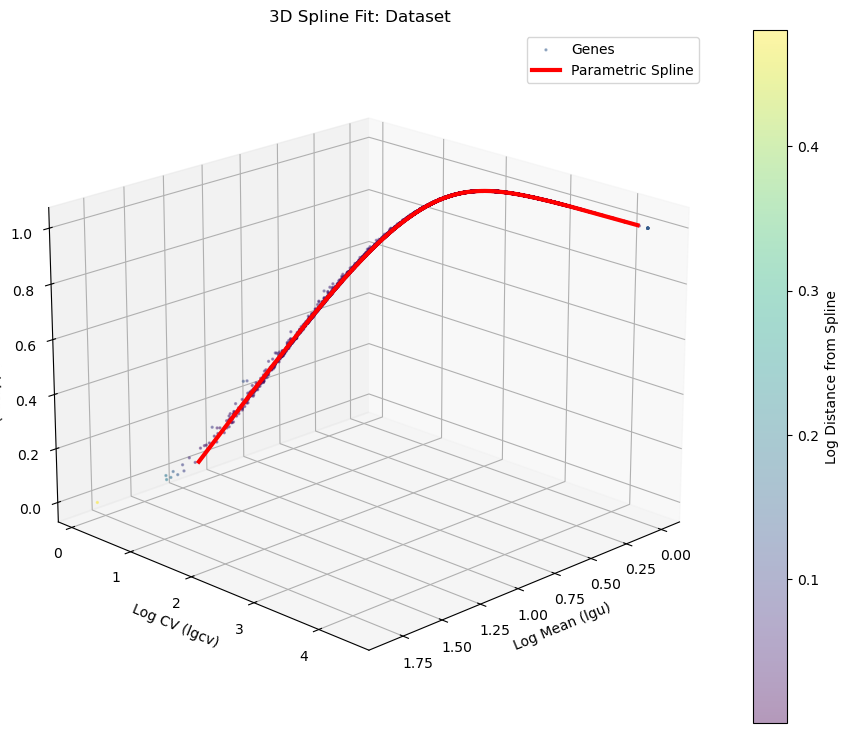

In [92]:
# Debugging sc_splinefit and sanity check of one label
crc_spline, crc_xyz, crx_xyz1 = sc_splinefit(adata=adata, obs_label="BatchID", label="CRC", n_pieces=15, beta=0.75)
plot_spline(crc_spline, crc_xyz, crx_xyz1)

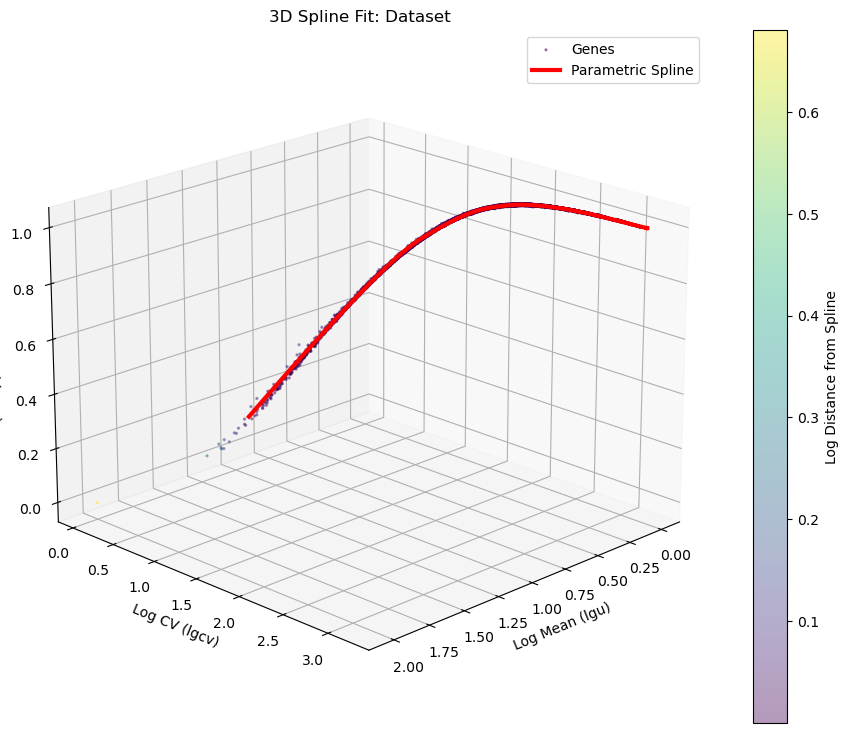

In [93]:
# Debugging sc_splinefit and sanity check of second label
crc_spline, crc_xyz, crx_xyz1 = sc_splinefit(adata=adata, obs_label="BatchID", label="Unaffected", n_pieces=15, beta=0.75)
plot_spline(crc_spline, crc_xyz, crx_xyz1)

In [97]:
# Final Analysis Call (Permutation)
results, adata1, adata2 = run_splinedv_on_adata(
    adata,
    cell_type_col = 'CellType',
    cell_type     = 'Epithelial cells',
    condition_col = 'BatchID',
    cond_1        = 'Unaffected',
    cond_2        = 'CRC',
    # Stats selection:
    method        = 'permutation',  # Options: 'permutation' or 'gaussian'
    n_perms       = 100,           # Only used if method='permutation'
    # QC and Spline Params:
    do_qc         = False,
    qc_params     = {'libsize': 1000, 'mtratio': 0.15, 'min_cells_nonzero': 15},
    fname         = 'results/epithelial_spline', 
    plotit        = True,
    beta          = 0.75
)

CRITICAL: Starting Cell-Shuffle Permutation (100 iterations).


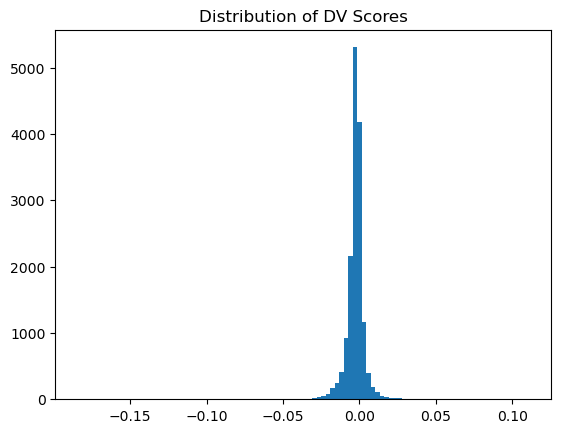

In [98]:
import matplotlib.pyplot as plt
plt.hist(results['dv_score'], bins=100)
plt.title("Distribution of DV Scores")
plt.show()

In [99]:
# Display top genes where CRC is more variable than Unaffected
print(results.sort_values('dv_score', ascending=False).head(10))

             gene  lgu_Unaffected  lgcv_Unaffected  dropr_Unaffected  \
9073       MT-CO1        1.058541         0.484141          0.239714   
5995   FP671120.1        0.987729         0.588556          0.341682   
4574        DACH1        0.205682         1.355086          0.885510   
9738        NRXN3        0.133086         1.536101          0.923077   
9566         NKD1        0.035493         2.139429          0.982111   
6516         GRM8        0.278087         1.303063          0.865832   
6042          FTX        0.833003         0.654751          0.434705   
1179   AC126178.1        0.150183         1.427830          0.901610   
14247       TRPM3        0.031252         2.183886          0.983900   
14801       VSIG2        0.187281         1.352590          0.880143   

       dist_Unaffected   lgu_CRC  lgcv_CRC  dropr_CRC  dist_CRC  mean_diff  \
9073          0.029440  1.428795  0.196665   0.012843  0.215486   0.370254   
5995          0.035571  1.407600  0.214779   0.0181

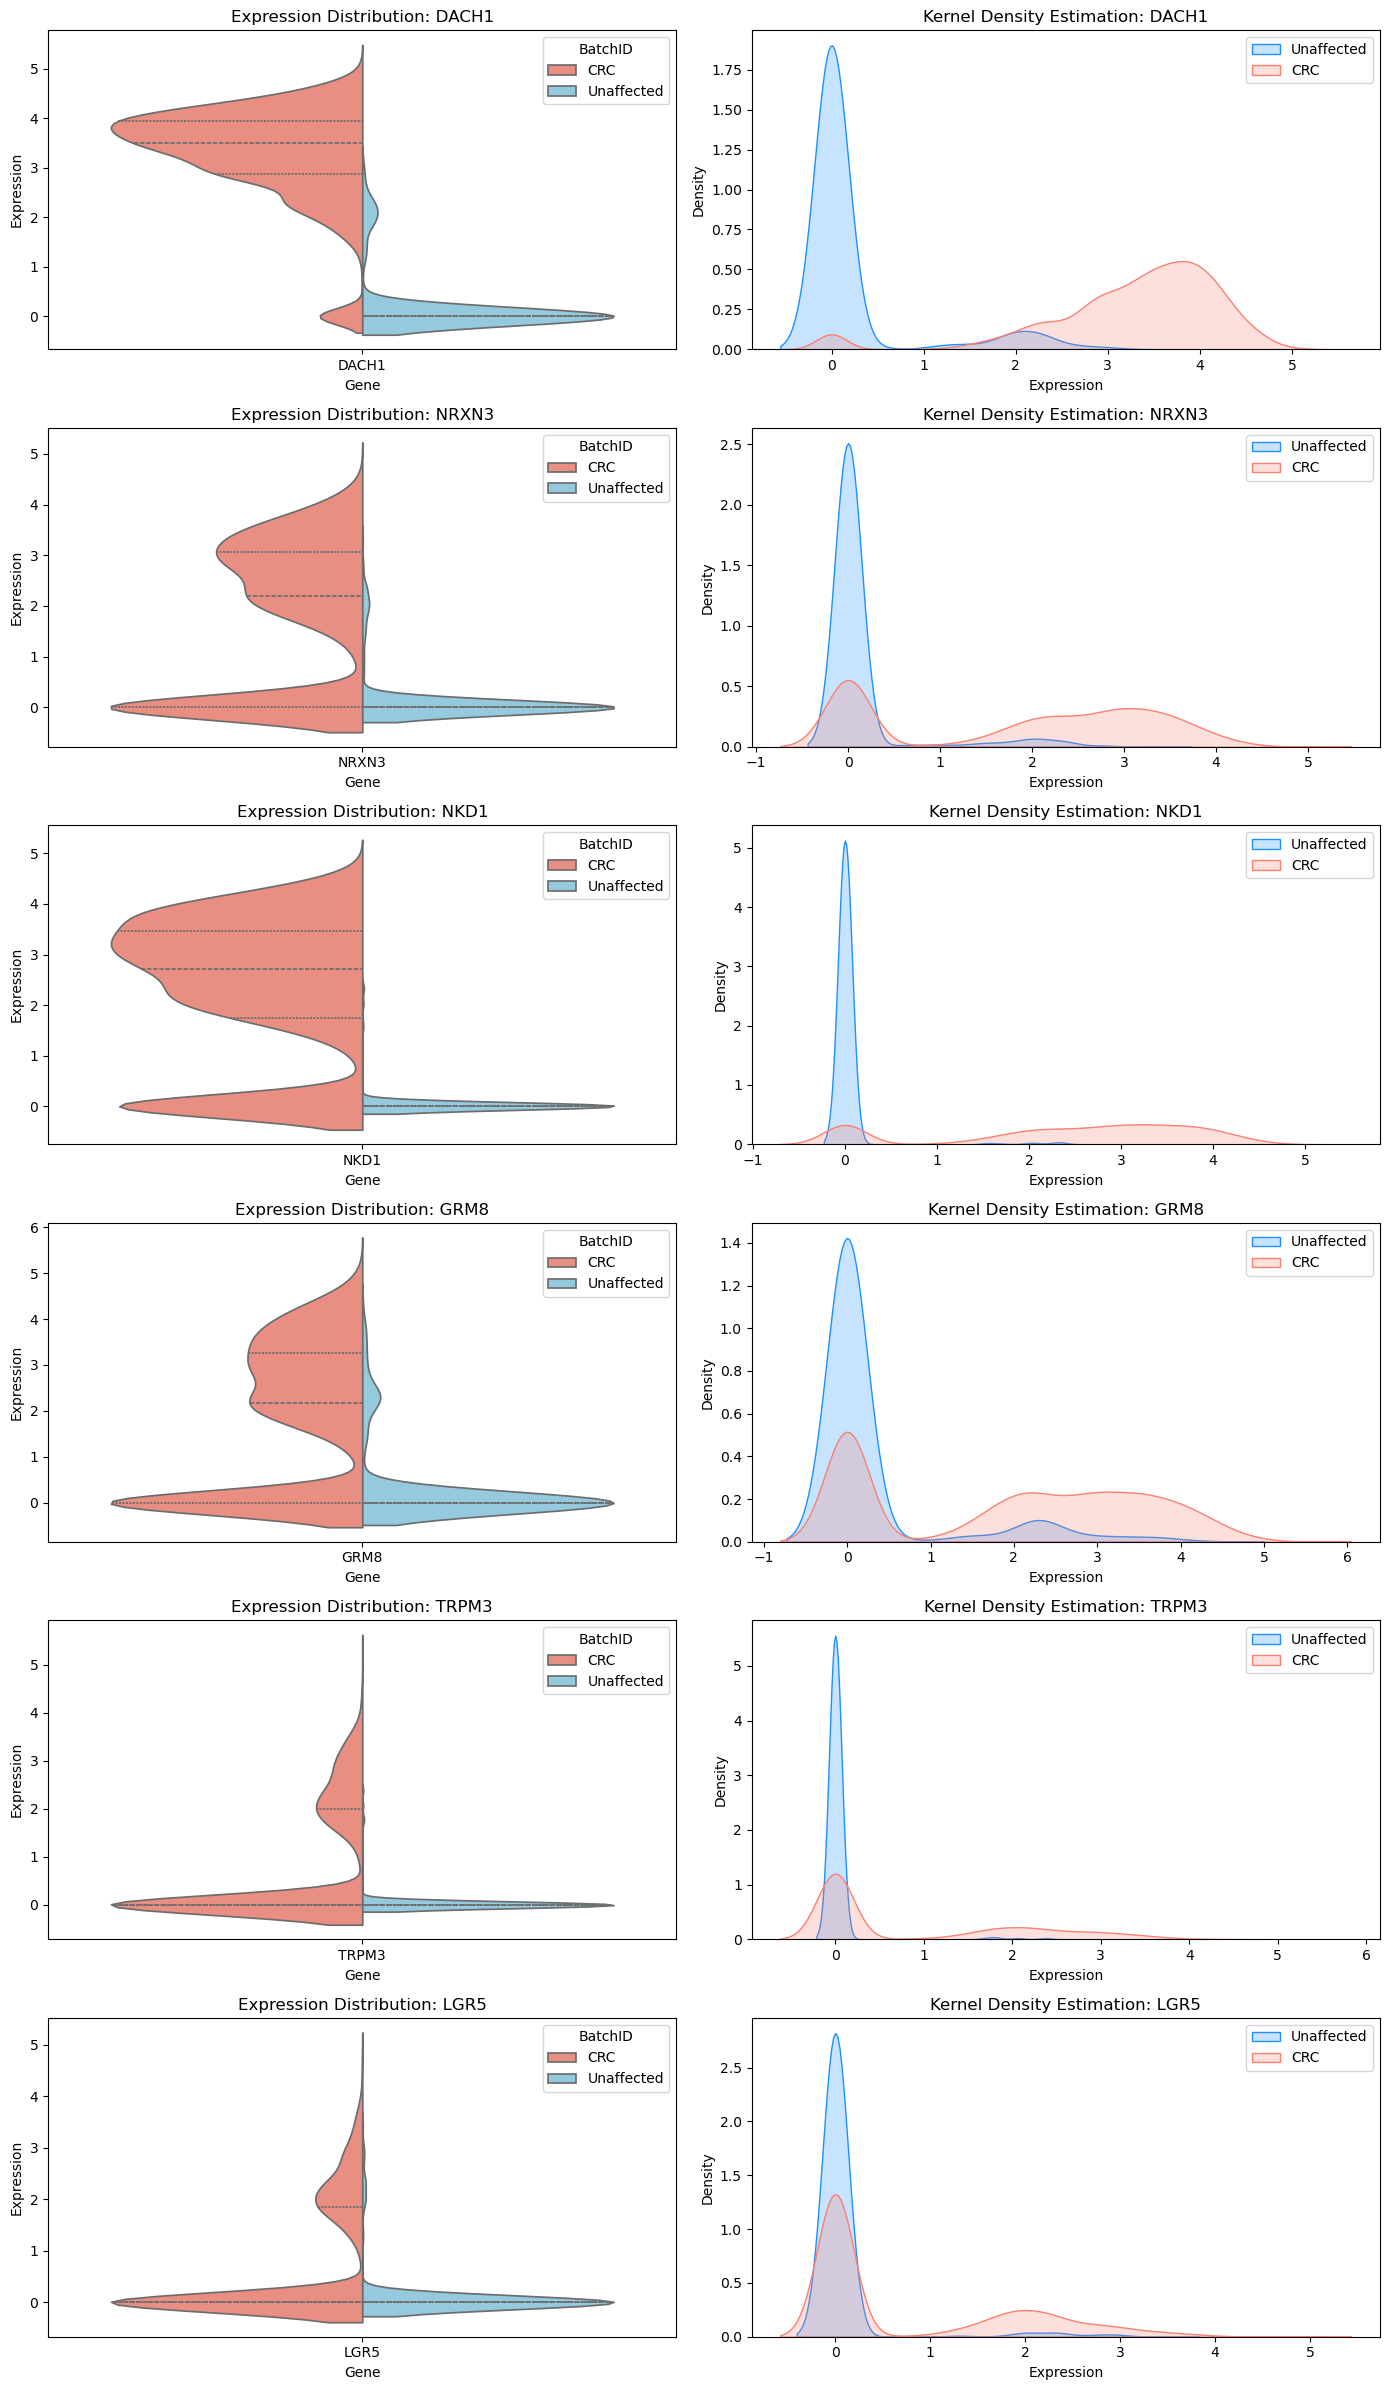

In [54]:
# --- EXECUTION ---
selected_genes = ['DACH1', 'NRXN3', 'NKD1', 'GRM8', 'TRPM3', 'LGR5']
plot_gene_distributions(adata, selected_genes, 'BatchID', 'Unaffected', 'CRC')